In [1]:
import numpy as np
import importlib
import h5py, sys, os
import pandas as pd

import astropy
import astropy.units as u
import astropy.constants as c
from astropy.cosmology import default_cosmology
from scipy.interpolate import RegularGridInterpolator

sys.path.append('/global/homes/c/cpopik/CAPPIBARAS/')
from Models import SHMRs, SMFs, HaloModels, HODs, Profiles, Data, FFTs, Spectra, Dust, Projections

In [2]:
# Plot Styling
import matplotlib.pyplot as plt
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

In [3]:
params = {
    "hh": {
        "value": 0.7},
    "Omega_L": {
        "value": 0.75},
    "Omega_m": {
        "value": 0.25},
    "Omega_b": {
        "value": 0.044},
    "T_CMB": {
        "value": 2.725},
    "XH": {
        "value": 0.76}, # hydrogen fraction
    "v_rms": {
        "value": 1.06e-3}   # v_rms/c, used for kSZ
}

cpars = {k: v["value"] for k, v in params.items() if isinstance(v, dict) and "value" in v}  

In [4]:
inputdict = {
    'SMF': {
        'name': 'DESI_LRGs_XCorr', 
        'spefs': {
            'pzbin':'1',
            'hemisphere':'combined',
            'sample':'main',}},
    'HOD': {
        'name':'Yuan2023', 
        'spefs': {
            'sample':'LRG 0.4<z<0.6'}},
    'SHMR': {
        'name':'Gao2023', 
        'spefs': {
            'sample':'ELG_Cross'}},
    'HMF': {
        'name':'pyccl', 
        'spefs': {
            'mfunc':'Tinker08', 
            'mdef':'200c', 
            'hbias':'Tinker10'}},
    
    'onehalo': {
        'name':'Amodeo2021', 
         'spefs': {
             'model':'GNFW'}},
    'twohalo': {
        'name':'Amodeo2021', 
         'spefs': {
             'model':'GNFW'}},
    'data': {
        'name':'Liu2025', 
         'spefs': {
             'zbin': '1', 
             'Beta':'1.2',
             'TCIB': '10.7',
             'dp': 'dBeta',
             'DR':'DR6'}},
    'dust': {
        'name':'Amodeo2021',
        'spefs': {
            'model':'ACT+Hershel'}}
    }

shmr = getattr(SHMRs, inputdict['SHMR']['name'])(inputdict['SHMR']['spefs'])
smf = getattr(SMFs, inputdict['SMF']['name'])(inputdict['SMF']['spefs'])
hod = getattr(HODs, inputdict['HOD']['name'])(inputdict['HOD']['spefs'])
hmod = getattr(HaloModels, inputdict['HMF']['name'])(inputdict['HMF']['spefs'])
Pth1hmodel = getattr(Profiles, inputdict['onehalo']['name'])(inputdict['onehalo']['spefs'])
Pth2hmodel = getattr(Profiles, inputdict['twohalo']['name'])(inputdict['twohalo']['spefs'])
tSZmeas = getattr(Data, inputdict['data']['name'])(inputdict['data']['spefs'])
tSZdust = getattr(Dust, inputdict['dust']['name'])(inputdict['dust']['spefs'])


In [5]:
dndlogmhalo_hmod_func = lambda zs, logmhalos: hmod.HMF(zs, logmhalos, **cpars)
bh = lambda zs, logmhalos: hmod.bh(zs, logmhalos, **cpars)
Plin = lambda ks, zs: hmod.Plin(ks, zs, **cpars)

cosmology = astropy.cosmology.LambdaCDM(H0=cpars["hh"]*100, Tcmb0=cpars['T_CMB'], Om0=cpars["Omega_m"], Ode0=cpars["Omega_L"], Ob0=cpars["Omega_b"])

H = lambda zs: cosmology.H(zs).to(u.km/u.s/u.Mpc).value
rhoc = lambda zs: cosmology.critical_density(zs).to(u.Msun/u.Mpc**3).value
dA = lambda zs: cosmology.angular_diameter_distance(zs).value
chi = lambda zs:cosmology.comoving_distance(zs).value
r200c = lambda zs, logmhalos: (10**logmhalos/(4/3*np.pi*200*rhoc(zs)[:, None]))**(1/3)

# Define r points and FFT
rs = np.logspace(-3, 2, 100)
fft = FFTs.mcfit_package(rs)
ks = fft.ks

ells = np.geomspace(55, 10000, 75)

# Mine

/global/homes/c/cpopik/CAPPIBARAS/Models/SMFs.py:45: RuntimeWarning: invalid value encountered in divide
  conv_fac = np.nan_to_num((np.trapz(dndlogmstar, logmstar)/np.trapz(dndlogmstar_interp, logmhalo)), nan=0.0)


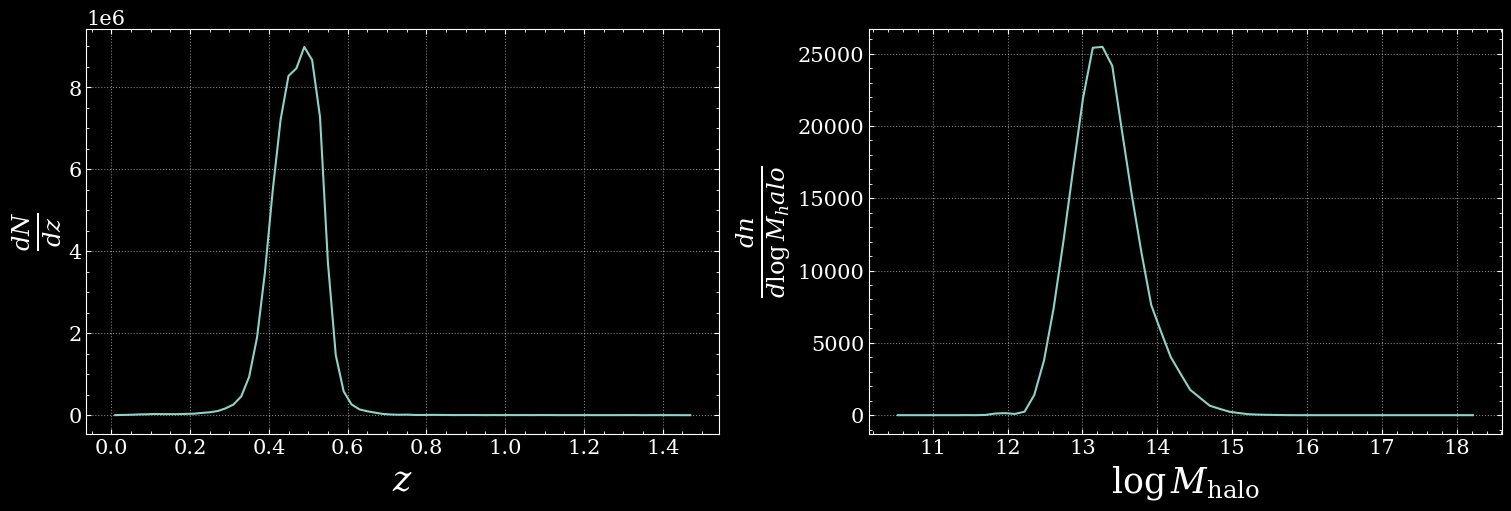

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

# Get the HMF from the SMF using a SHMR, and get a zdist
logmhalo_smf, dndlogmhalo_smf_raw = smf.hmf_from_smf(lambda mstar: shmr.SHMR(mstar)(), **cpars)
dNdz_raw = np.trapz(smf.dndlogmstar(**cpars), smf.logmstar)*smf.volumes(**cpars)/(smf.z[1]-smf.z[0])

axs[0].plot(smf.z, dNdz_raw)
axs[1].plot(logmhalo_smf, np.trapz(dndlogmhalo_smf_raw*smf.volumes(**cpars)[:, None], smf.z, axis=0))

axs[0].set(xlabel=r'$z$', ylabel=r'$\frac{dN}{dz}$')
axs[1].set(xlabel=r'$\log M_\text{halo}$', ylabel=r'$\frac{dn}{d\log M_halo}$')

plt.show()

In [8]:
# Define z and m points
zbins = np.linspace(0.3, 0.6, 11)
logmhalobins = np.linspace(12, 15, 51)
logmhalos, zs = (logmhalobins[1:]+logmhalobins[:-1])/2, (zbins[1:]+zbins[:-1])/2

# Interpolate to desired points
intp_points = np.stack(np.meshgrid(zs, logmhalos, indexing='ij'), axis=-1)
dndlogmhalo_smf = RegularGridInterpolator((smf.z, logmhalo_smf), dndlogmhalo_smf_raw, bounds_error=False, fill_value=np.nan)(intp_points)
dNdz = np.trapz(dndlogmhalo_smf, logmhalos)*smf.volumes(zs=zs, **cpars)/(zs[1]-zs[0])

Hs, rhocs, r200cs = H(zs), rhoc(zs), r200c(zs, logmhalos)
Plins, bhs = Plin(ks, zs), bh(zs, logmhalos)
chis = chi(zs)

Pth1h = Pth1hmodel.Pth1h(rs, zs, logmhalos, rhocs, r200cs, **cpars)
Pth2h = lambda p={}: Pth2hmodel.Pth2h(rs, zs, logmhalos, rhocs, r200cs, Plins, bhs, dndlogmhalo_smf, fft.FFT3D, fft.IFFT3D, ks, **cpars)(p)[..., None]
Pth = lambda params={}: Pth1h(params)+Pth2h(params)

Nc, Ns = hod.Nc(logmhalos), hod.Ns(logmhalos)
uck, usk = hod.uck(), hod.usk(rs, r200cs, fft.FFT3D)
dndlogmhalo_hmod = dndlogmhalo_hmod_func(zs, logmhalos)

Cgg1hk = Spectra.Kou2023().Cgg1h(ells, ks, zs, chis, Hs, dNdz, Nc, Ns, usk, logmhalos, dndlogmhalo_hmod)
Cgg2hk = Spectra.Kou2023().Cgg2h(ells, ks, zs, chis, Hs, dNdz, Nc, Ns, usk, logmhalos, dndlogmhalo_hmod, bhs, Plins)
SNk = Spectra.Kou2023().SN(ells, smf.info['area'], dNdz, zs)

Cgy1hk = Spectra.Kou2023().Cgy1h(ells, ks, zs, chis, Hs, dNdz, Nc, Ns, usk, logmhalos, dndlogmhalo_hmod, fft.FFT3D, tSZmeas.beam_ells, tSZmeas.beam_data, **cpars)
Cgy2hk = Spectra.Kou2023().Cgy2h(ells, ks, zs, chis, Hs, dNdz, Nc, Ns, usk, logmhalos, dndlogmhalo_hmod, fft.FFT3D, bhs, Plins, tSZmeas.beam_ells, tSZmeas.beam_data, **cpars)

In [9]:
importlib.reload(HODs)
hod = getattr(HODs, inputdict['HOD']['name'])(inputdict['HOD']['spefs'])
Nc, Ns = hod.Nc(logmhalos), hod.Ns(logmhalos)
uck, usk = hod.uck(), hod.usk(rs, r200cs, fft.FFT3D)
dndlogmhalo_hmod = dndlogmhalo_hmod_func(zs, logmhalos)

In [ ]:
# import sys
# sys.path.append('/global/homes/c/cpopik/')
# from Basics import *

# cellspath = ("/global/homes/c/cpopik/Stacking_Correlating")
# ViewDataOrganization(cellspath)

# with h5py.File("/global/homes/c/cpopik/Stacking_Correlating/ACTDR6DESILRG_Spectra_NEW.h5", "r") as f:
#     print("Keys:", list(f['TxI'].keys()))
#     print("Keys:", list(f['TxI/cib_cibdBeta_cibdT/1/'].keys()))

No README file
/global/homes/c/cpopik/Stacking_Correlating/                                                           (288 MB) 4 Dirs
     ACTDR6DESILRG_Spectra_testnew.h5                                                                         (1 MB)
     untitled.txt                                                                                             (1 MB)
     Stacking Target Stamps from Maps.ipynb                                                                   (1 MB)
     untitled.py                                                                                              (1 MB)
     DESI_Catalogs.ipynb                                                                                      (2 MB)
     ACTDR6DESILRG_Spectra_NEW2.h5                                                                            (1 MB)
     dataplotting.py                                                                                          (1 MB)
     .ipynb_checkpoints/                       

/global/homes/c/cpopik/CAPPIBARAS/Models/HODs.py:31: RuntimeWarning: invalid value encountered in power
  nsat = ((M-M_0)/M_1)**alpha


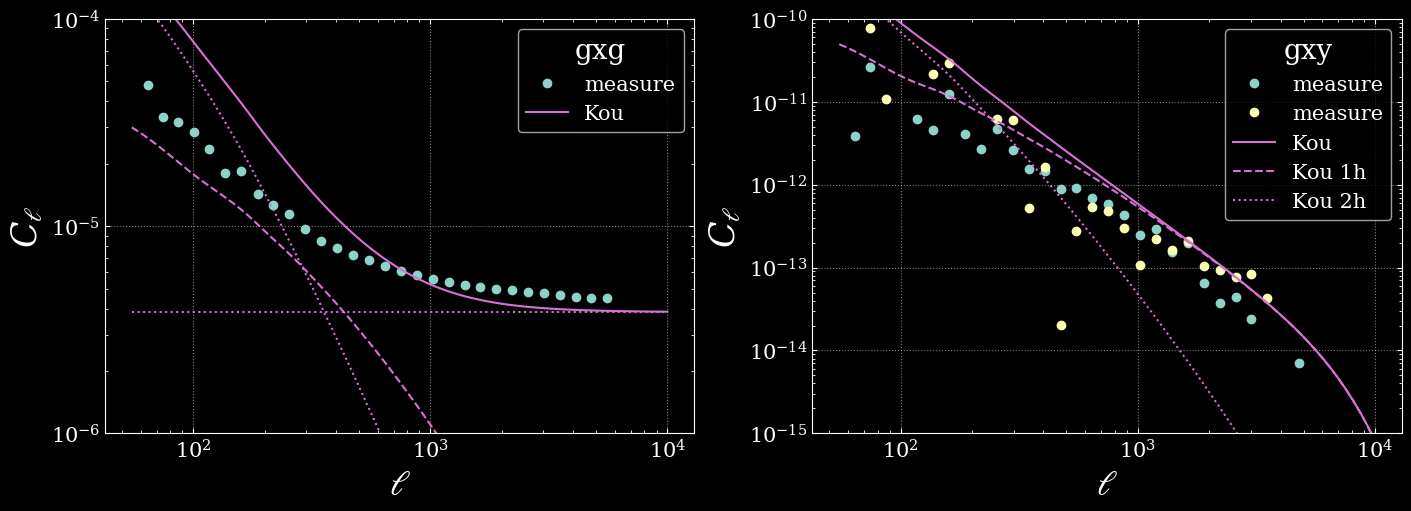

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), layout='constrained')


with h5py.File("/global/homes/c/cpopik/Stacking_Correlating/ACTDR6DESILRG_Spectra_NEW.h5", "r") as f:
    axs[0].loglog(f['ell'][()], f['TxT/1'][()], label='measure', marker='o', ls='')
    axs[1].loglog(f['ell'][()], f['TxI/cib_cibdBeta/1/1.2_10.7'][()], label='measure', marker='o', ls='')
    axs[1].loglog(f['ell'][()], f['TxI/cib_cibdBeta_cibdT/1/1.6_10.7'][()], label='measure', marker='o', ls='')
    
axs[0].loglog(ells, (Cgg1hk()+Cgg2hk())+SNk, label='Kou', c='orchid')
axs[0].loglog(ells, Cgg1hk(), ls='--', c='orchid')
axs[0].loglog(ells, Cgg2hk(),ls=':', c='orchid')
axs[0].loglog(ells, SNk, ls=':', c='orchid')

axs[1].loglog(ells, (Cgy1hk(Pth())+Cgy2hk(Pth())), label='Kou', c='orchid')
axs[1].loglog(ells, Cgy1hk(Pth()), label='Kou 1h', ls='--', c='orchid')
axs[1].loglog(ells, Cgy2hk(Pth()), label='Kou 2h', ls=':', c='orchid')


axs[0].set(ylim=(1e-6, 1e-4), ylabel=r'$C_\ell$', xlabel='$\ell$'); axs[0].legend(title='gxg')
axs[1].set(ylim=(1e-15, 1e-10), ylabel=r'$C_\ell$', xlabel='$\ell$'); axs[1].legend(title='gxy')

plt.show()

# Kou 2023

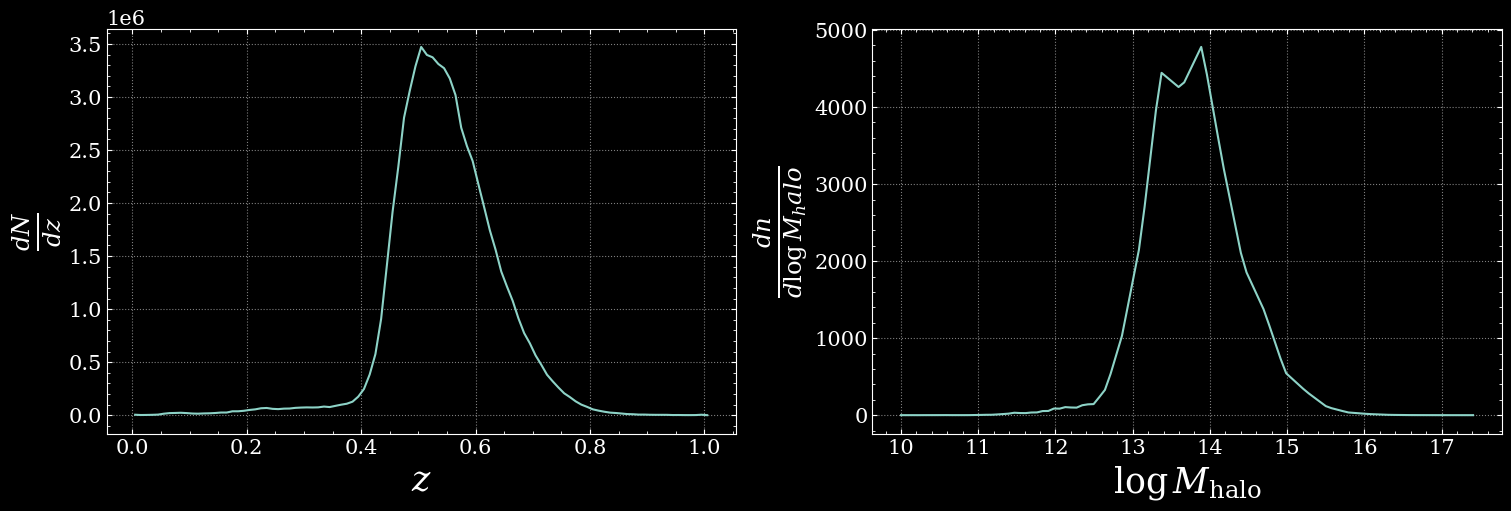

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

# Get the HMF from the SMF using a SHMR, and get a zdist
smf = SMFs.BOSS_DR10({'galaxy':'CMASS','group':'portsmouth','template':'passive','IMF':'Kroupa',})
smf.make_SMF()
logmhalo_smf, dndlogmhalo_smf_raw = smf.hmf_from_smf(lambda mstar: shmr.SHMR(mstar)(), **cpars)
dNdz_raw = np.trapz(smf.dndlogmstar(**cpars), smf.logmstar)*smf.volumes(**cpars)/(smf.z[1]-smf.z[0])

axs[0].plot(smf.z, dNdz_raw)
axs[1].plot(logmhalo_smf, np.trapz(dndlogmhalo_smf_raw*smf.volumes(**cpars)[:, None], smf.z, axis=0))

axs[0].set(xlabel=r'$z$', ylabel=r'$\frac{dN}{dz}$')
axs[1].set(xlabel=r'$\log M_\text{halo}$', ylabel=r'$\frac{dn}{d\log M_halo}$')

plt.show()

In [21]:
# Define z and m points
zbins = np.linspace(0.47, 0.59, 11)
logmhalobins = np.linspace(12.57, 15.5, 51)
logmhalos, zs = (logmhalobins[1:]+logmhalobins[:-1])/2, (zbins[1:]+zbins[:-1])/2

# Interpolate to desired points
intp_points = np.stack(np.meshgrid(zs, logmhalos, indexing='ij'), axis=-1)
dndlogmhalo_smf = RegularGridInterpolator((smf.z, logmhalo_smf), dndlogmhalo_smf_raw, bounds_error=False, fill_value=np.nan)(intp_points)
dNdz = np.trapz(dndlogmhalo_smf, logmhalos)*smf.volumes(zs=zs, **cpars)/(zs[1]-zs[0])

Hs, rhocs, r200cs = H(zs), rhoc(zs), r200c(zs, logmhalos)
Plins, bhs = Plin(ks, zs), bh(zs, logmhalos)
chis = chi(zs)

hod = HODs.Kou2023({'sample':'M*>10.8'})
Nc, Ns = hod.Nc(logmhalos), hod.Ns(logmhalos)
uck, usk = hod.uck(), hod.usk(rs, r200cs, fft.FFT3D)
dndlogmhalo_hmod = dndlogmhalo_hmod_func(zs, logmhalos)

Cgg1hk = Spectra.Kou2023().Cgg1h(ells, ks, zs, chis, Hs, dNdz, Nc, Ns, usk, logmhalos, dndlogmhalo_hmod)
Cgg2hk = Spectra.Kou2023().Cgg2h(ells, ks, zs, chis, Hs, dNdz, Nc, Ns, usk, logmhalos, dndlogmhalo_hmod, bhs, Plins)
SNk = Spectra.Kou2023().SN(ells, 1000, dNdz, zs)

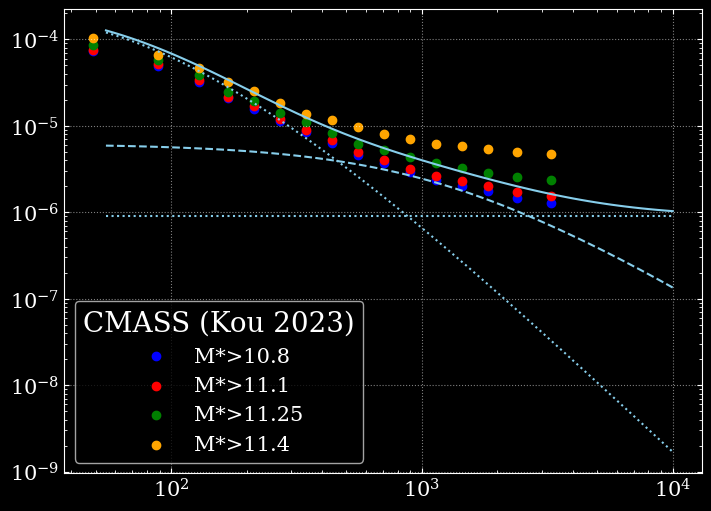

In [13]:
importlib.reload(Data)

fig, ax = plt.subplots(1, 1, figsize=(7, 5), layout='constrained')
ax.set(xscale='log', yscale='log')

kou = Data.Kou2023({'mbin':'1'})
ax.scatter(kou.dgg_ells, kou.cgg, c='blue', label='M*>10.8')
ax.scatter(kou.dgg_ells, Data.Kou2023({'mbin':'2'}).cgg, c='red', label='M*>11.1')
ax.scatter(kou.dgg_ells, Data.Kou2023({'mbin':'3'}).cgg, c='green', label='M*>11.25')
ax.scatter(kou.dgg_ells, Data.Kou2023({'mbin':'4'}).cgg, c='orange', label='M*>11.4')
ax.legend(title='CMASS (Kou 2023)')

ax.loglog(ells, (Cgg1hk()+Cgg2hk())+SNk, label='Kou Model M*>11.1', c='skyblue')
ax.loglog(ells, Cgg1hk(), ls='--', c='skyblue')
ax.loglog(ells, Cgg2hk(),ls=':', c='skyblue')
ax.loglog(ells, SNk, ls=':', c='skyblue')

plt.show()

# Kusiak

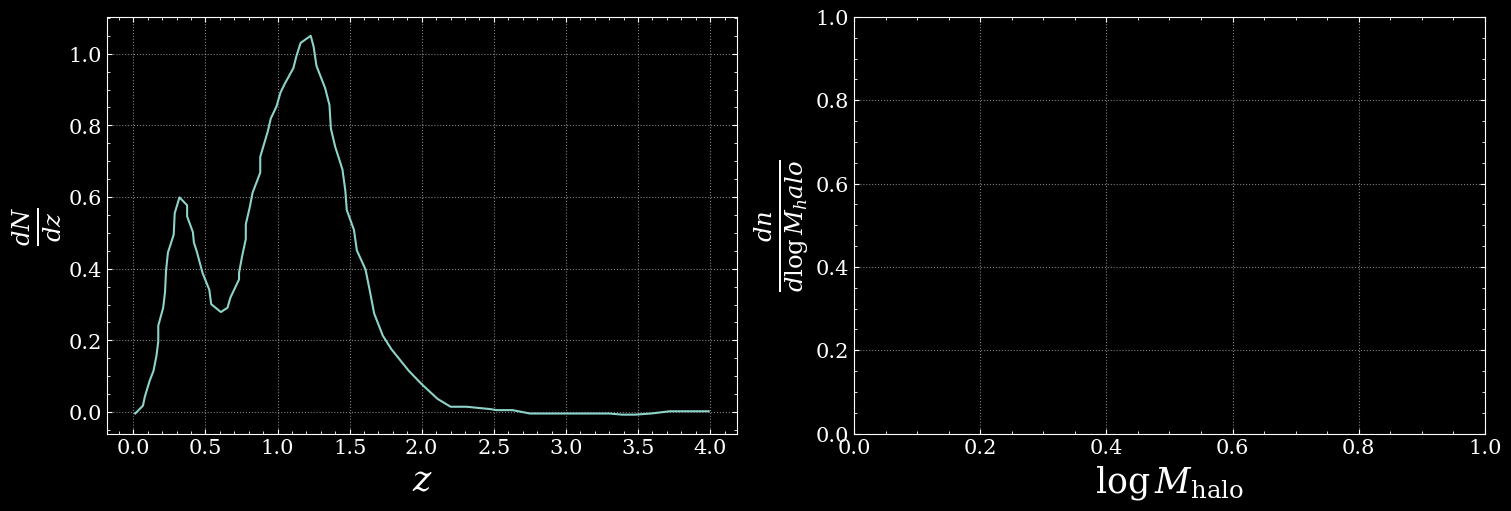

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

z_raw = np.array([
    0.0133, 0.0667, 0.0800, 0.113, 0.140, 0.160, 0.173, 0.173, 0.207, 0.220,
    0.227, 0.240, 0.280, 0.287, 0.320, 0.373, 0.373, 0.413, 0.420, 0.440,
    0.480, 0.527, 0.540, 0.607, 0.653, 0.673, 0.733, 0.733, 0.753, 0.780,
    0.780, 0.807, 0.827, 0.880, 0.880, 0.933, 0.953, 0.993, 1.02, 1.05, 1.11,
    1.13, 1.16, 1.23, 1.25, 1.27, 1.33, 1.36, 1.37, 1.40, 1.45, 1.47, 1.48,
    1.53, 1.55, 1.61, 1.64, 1.67, 1.73, 1.79, 1.84, 1.91, 2.00, 2.11, 2.20,
    2.31, 2.39, 2.47, 2.52, 2.63, 2.75, 2.83, 2.98, 3.06, 3.20, 3.30, 3.39,
    3.48, 3.59, 3.72, 3.85, 3.94, 3.99
])

dndz_raw = np.array([
   -0.00419, 0.0178, 0.0429, 0.0869, 0.115, 0.156, 0.197, 0.241, 0.291, 0.335,
    0.395, 0.445, 0.495, 0.555, 0.599, 0.577, 0.546, 0.502, 0.473, 0.448,
    0.388, 0.341, 0.301, 0.279, 0.291, 0.319, 0.370, 0.388, 0.432, 0.483,
    0.524, 0.571, 0.612, 0.668, 0.712, 0.784, 0.819, 0.853, 0.891, 0.916, 0.960,
    0.992, 1.03, 1.05, 1.02, 0.966, 0.904, 0.857, 0.791, 0.740, 0.677, 0.618,
    0.564, 0.508, 0.451, 0.398, 0.338, 0.275, 0.213, 0.175, 0.150, 0.115,
    0.0775, 0.0366, 0.0147, 0.0147, 0.0115, 0.00838, 0.00524, 0.00524,
   -0.00419, -0.00419, -0.00419, -0.00419, -0.00419, -0.00419, -0.00733,
   -0.00733, -0.00419, 0.00209, 0.00209, 0.00209, 0.00209
])


axs[0].plot(z_raw, dndz_raw)
# axs[1].plot(logmhalo_smf, np.trapz(dndlogmhalo_smf_raw*smf.volumes(**cpars)[:, None], smf.z, axis=0))

axs[0].set(xlabel=r'$z$', ylabel=r'$\frac{dN}{dz}$')
axs[1].set(xlabel=r'$\log M_\text{halo}$', ylabel=r'$\frac{dn}{d\log M_halo}$')

plt.show()

In [15]:
# Define z and m points
zbins = np.linspace(0, 4, 11)
logmhalobins = np.linspace(9, 14.7, 51)
logmhalos, zs = (logmhalobins[1:]+logmhalobins[:-1])/2, (zbins[1:]+zbins[:-1])/2

# Interpolate to desired points
dNdz = np.interp(zs, z_raw, dndz_raw)
ntot = 1846*0.575*41253
dNdz = dNdz * ntot

Hs, rhocs, r200cs = H(zs), rhoc(zs), r200c(zs, logmhalos)
Plins, bhs = Plin(ks, zs), bh(zs, logmhalos)
chis = chi(zs)

hod = HODs.Kou2023({'sample':'M*>10.8'})
Nc, Ns = hod.Nc(logmhalos), hod.Ns(logmhalos)
uck, usk = hod.uck(), hod.usk(rs, r200cs, fft.FFT3D)
dndlogmhalo_hmod = dndlogmhalo_hmod_func(zs, logmhalos)

Cgg1ho = Spectra.Kusiak2023().Cgg_1h(Nc, Ns, usk, dndlogmhalo_hmod, logmhalos, Hs, chis, dNdz, zs, ells, ks)
Cgg2ho = Spectra.Kusiak2023().Cgg_2h(ells, Nc, Ns, usk, dndlogmhalo_hmod, logmhalos, Hs, chis, dNdz, zs, ks, Plins, bhs)
SNo = Spectra.Kusiak2023().SN(0.575*41253, dNdz, ells, zs)

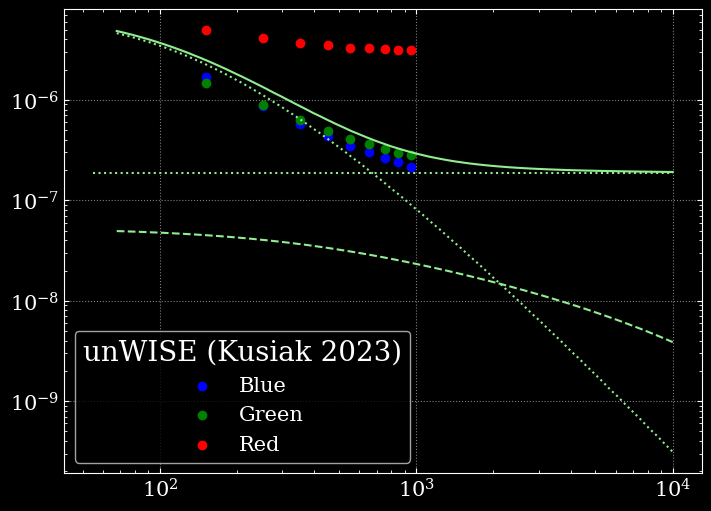

In [19]:
importlib.reload(Data)

fig, ax = plt.subplots(1, 1, figsize=(7, 5), layout='constrained')
ax.set(xscale='log', yscale='log')

kusiak = Data.Kusiak2023({'color':'blue'})
ax.scatter(kusiak.ells, kusiak.cgg, c='blue', label='Blue')
ax.scatter(kusiak.ells, Data.Kusiak2023({'color':'green'}).cgg, c='green', label='Green')
ax.scatter(kusiak.ells, Data.Kusiak2023({'color':'red'}).cgg, c='red', label='Red')
ax.legend(title='unWISE (Kusiak 2023)')

ax.loglog(ells, (Cgg1ho()+Cgg2ho())+SNo, label='Kou Model M*>11.1', c='lightgreen')
ax.loglog(ells, Cgg1ho(), ls='--', c='lightgreen')
ax.loglog(ells, Cgg2ho(),ls=':', c='lightgreen')
ax.loglog(ells, SNo, ls=':', c='lightgreen')

plt.show()

# Testing